# AI Agents for Scientific Simulation and Data Analysis

Computational scientists come from diverse domains and backgrounds, but they tend to use HPC in similar ways: one runs a simulation and processes data, iterating until a new observation emerges. The bulk of scientific reasoning happens in the interpretation of these simulations, but as scientific computation becomes more sophisticated and resource-heavy, researchers can spend undue time on tasks like debugging, environment setup, and convergence checks. Is there a way to automate some of these setup tasks, and allow scientists to focus on refining their hypotheses?

The answer is yes, and the trick is to program an agent to run and execute code. This leaves the agent to handle the cumbersome aspects of numerical work, while the researcher is free to interpret results, come up with new hypotheses, and plan further simulations. In this tutorial we will build an agent that can generate and execute Python code, giving it access to NumPy, SciPy, and a host of other packages for scientific computing. Specifically, we will:

- **Part 1**: Build an agent to write and run Python code
- **Part 2**: Use the agent to write and run a scientific simulation
- **Part 3**: Use the agent to process a scientific dataset

We will build our agent using the basic framework introduced in our first tutorial, with a few key augmentations for code generation. Let's get started!


In [1]:
# Optional: Refresh demo output folders before proceeding
! rm -r generated_code
! rm -r images
! mkdir generated_code
! mkdir images

## Part 1: Build an agent to write and run Python code

The cornerstone of our agent framework is structured generation, and the basic building blocks of our coder-agent will look very familiar those discussed in our first tutorial. That is, we will connect to an LLM backend, setup schema and tool calls for generating python code, and adjust our agent's reasoning loop with these new capabilities. Let's explore each of these broad steps in detail before seeing the completed agent in action.


### Connect to an LLM Backend
```
openai_client = OpenAI(
            api_key="ollama", 
            base_url="http://localhost:11434/v1"
            )
backend_model = from_openai(openai_client, model_name='qwen3-coder:30b')
```
Just like our introductory tutorial, the first step of this demo is to establish an LLM backend. As we'll see later in the tutorial, the choice of backend is one of the most significant determining factors in an agent's performance. For this tutorial, we'll connect to a modestly sized coding model (qwen3-coder:30b) running on a local Ollama server, but keep in mind that this choice can be substituted for any model/provider with an OpenAI-compatible endpoint. 


### Set up schema for code generation
```
class GenerateCode(BaseModel):
    thoughts: str = Field(..., description="Reasoning about how to solve the coding task")
    code: str = Field(..., description="Python code as a string that solves the task, must include uv install of dependencies")

    def execute(self):
        result = self.run_python_in_docker(self.code)
        return result

class AgentAction(BaseModel):
    thought: str = Field(..., description="Internal reasoning about what to do next.")
    action: Optional[GenerateCode] = Field(None, description="Tool call if calculation is needed.")
    final_summary: Optional[str] = Field(None, description="Final answer to the request when ready.")        
```

Here, we use Pydantic to define two schema for our code generation task. These include GenerateCode, which functions similar to the ToolCall from our initial tutorial, and AgentAction, which functions as a ReAct-style reasoning module. Note that the code generation schema also includes a method called self.execute(), which executes the code generated by the schema. Tool calls like this are handled explicitly in the agent's reasoning loop.

### Update the agent's reasoning loop

```
def generate_code_agent(max_steps: int = 3):
    for step in range(0, max_steps):
        response = backend_model(prompt, AgentAction)
        if response.action:
            result = response.action.execute()
            observations.append(result)
        elif response.final_summary:
            return response.final_summary
        else:
            print('Could not formulate next step')
            break
```

Thus far we have given our agent the ability to generate code, but we have yet to tell the agent what to do with it. One way to permit code execution is via explicit tool call in the agent's reasoning loop. If the current step's LLM call returns code, we instruct the agent to execute the code via the GenerateCode schema's self.execute() method. Keep in mind that code generation/execution is generic here; if we wanted to replace GenerateCode with a different tool call, we would need only to write a new schema with the appropriate execute() method. We choose code generation for this tutorial because of the flexibility it provides.

### Update the agent's prompt

```
generate_code_template = Template.from_file('prompt_for_coder_agent.txt')
context = generate_code_template(
                user_task=user_input,
                prev_code=prev_code or "None",
                prev_error=prev_error or "None")
```

Having updated the schema and reasoning loop, the final component of our agent is its prompt. This is where we give the LLM guidelines and explicit instructions regarding how it should populate the fields of our schema. Because we are interested in generating usable code, we update our prompt to include explicit instructions regarding how code should be formatted, along with a simple example script as a template. In general, prompts are problem-dependent, but we find that a short list of requirements and a basic template are sufficient for most coding agents.

With all of the ingredients in place, let's have a look at the complete script:

In [2]:
from outlines import from_openai, Template
from pydantic import BaseModel, Field
from openai import OpenAI
from typing import Optional, List, Dict
import json
import subprocess
import os, uuid
import tempfile
import shutil, sys


# Connect to an LLM Backend
openai_client = OpenAI(
            api_key="ollama", 
            base_url="http://localhost:11434/v1"
            )
backend_model = from_openai(openai_client, model_name='qwen3-coder:30b')


# Set up schema for code generation, with a class method for executing the code
class GenerateCode(BaseModel):
    thoughts: str = Field(..., description="Reasoning about how to solve the coding task")
    code: str = Field(..., description="Python code as a string that solves the task, must include uv install of dependencies")

    # General action execution method
    def execute(self):
        result = self.run_python_in_docker(self.code)
        return result

    # Specific method for running code in a docker container
    def run_python_in_docker(self,code: str):

        # Write code to script
        work_dir = os.getcwd()
        tmpdir = tempfile.mkdtemp(dir=work_dir)
        script_path = os.path.join(tmpdir, "script.py")
        with open(script_path, "w") as f:
            f.write(code)

        # Set environment variables for 
        os.environ["TMPDIR"] = tmpdir
        os.environ["PYTHONPATH"] = tmpdir
        docker_cmd = ["python",f"{script_path}"]
        
        # Run code
        result = subprocess.run(docker_cmd,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,timeout=5 * 60)
        success = (result.returncode == 0)
        output = result.stdout

        # Save a copy of generated code if successful
        if success:
            filename = 'generated_code/' + f"generated_code_{uuid.uuid4().hex[:8]}.py"
            with open(filename, "w", encoding="utf-8") as f:
                f.write(code)

        # Cleanup
        shutil.rmtree(tmpdir)
        del os.environ["TMPDIR"]
        del os.environ["PYTHONPATH"]

        # Return code exit status
        return {
            "success": success,
            "output": output,
        }

# Set up schema for reasoning module
class AgentAction(BaseModel):
    thought: str = Field(..., description="Internal reasoning about what to do next.")
    action: Optional[GenerateCode] = Field(None, description="Tool call if code should be generated by the current step.")
    final_summary: Optional[str] = Field(None, description="Final summary when code generation is complete.")          

    
# Main agent reasoning loop
def generate_code_agent(user_input: str, max_steps, model):

    # Initialize the prompt with code generation instructions (the full prompt can be found in generate_code_template.txt)
    generate_code_template = Template.from_file('generate_code_template.txt')
    context = generate_code_template(
                user_task=user_input)

    messages: List[Dict] = [{"role": "user", "content": context}]
    observations = []

    # Loop through steps
    for step in range(max_steps):
        print(f"\n--- Step {step + 1} ---")
        prompt = "\n".join([f"{m['role']}: {m['content']}" for m in messages[-4:]])
        if observations:
            prompt += f"\nLatest Observation: {observations[-1]}"

        # Generate structured response
        try:
            response = model(prompt, AgentAction)
            action_obj = (
                response if isinstance(response, AgentAction)
                else AgentAction.model_validate_json(response)
            )
        except Exception as e:
            print(f"Parse error: {e}")
            return {"error": "Generation failed"}

        # Handle tool calls
        if action_obj.action:
            print(f"Thought: {action_obj.thought}")
            tool = action_obj.action
            print(f"Tool Call: {tool.__class__.__name__}")
            result = action_obj.action.execute()

            if result['success']:
                print(f"Code generation returned 'success' with the following output: \n{result['output']}")
                observation = f"Code generation suceeded. Here is the generated code that solved the user's task:\n\n" f"{action_obj.action.code}\n\n" f"Execution result:\n{result['output']}"
                
            else:
                print(f"Code generation failed with the following output: \n{result['output']}")
                observation = f"Code generation failed. Here is the generated code that failed to solve the user's task:\n\n" f"{action_obj.action.code}\n\n" f"Execution result:\n{result['output']}"
            observations.append(observation)    
            
            messages.extend([
                {"role": "assistant", "content": f"Action: {tool.__class__.__name__}"},
                {"role": "system", "content": observation}
            ])
        
        elif action_obj.final_summary:
            print(f"The task is complete. Here is a final summary of my work: \n{action_obj.final_summary}")
            return action_obj.final_summary

        else:
            print("No action or final summary returned.")
            break

    return {"error": f"Max steps ({max_steps}) reached without generated code"}    
    
# Simple test case
user_input = "Generate a Python Code that adds two integers. Use the code to answer: 1+1=?"
result = generate_code_agent(user_input = user_input, max_steps = 3, model=backend_model)



--- Step 1 ---
Thought: The user wants to generate a Python code that adds two integers and then compute 1+1. Since this is a very simple task, I can write the code directly without needing any external dependencies. The code should first install uv, then install any required packages (though none are needed for this task), and finally execute the addition.
Tool Call: GenerateCode
Code generation returned 'success' with the following output: 
1 + 1 = 2


--- Step 2 ---
The task is complete. Here is a final summary of my work: 
I have generated a Python code that adds two integers. The code correctly calculates 1 + 1 = 2 and prints the result. The solution follows all specified requirements including the use of uv for package management and proper code structure.


Note that our GenerateCode action has been configured such that any executed code is saved in the generated_code folder. We can check the contents of this folder, and see that the agent did indeed write a code that answers our request.

In [3]:
# Check the contents of the generate code directory
os.listdir('generated_code')

['generated_code_3d839716.py']

## Part 2:  Use the agent to write and run a scientific simulation

The framework above is simple but powerful. By giving the agent authority to execute Python, many scientific computing tasks reduce to communicating domain-specific requirements through the prompt and tool handling. This is one reason why 'prompt engineering' has become such a popular topic in recent years. The user can ask the agent simple request like 'use python to run a fluid dynamics simulation" and the agent in theory has the tools to write and execute such a script without further intervention.

For some scientific disciplines, this degree of autonomy presents an issue. Particularly in the case of compute-heavy simulations (e.g., fluid dynamics, computational chemistry, structural mechanics), one risks draining computational resources if the setup parameters are chosen carelessly. What's more, legacy simulation codes often lack complete documentation, making it even harder to setup guardrails for the agent. This is the domain of bespoke coding agents, in which an agent's prompt, tools, and reasoning modules are heavily refined for tasks native to a specific sub-domain. 

In this part of the tutorial, we will stick to very simple, canonical simulations that a general-purpose coding agent should be capable of setting up. As an starting point, let's see if we can configure our coder-agent to simulate an introductory physics problem: the simple pendulum. The goal of this exercise is to further populate the prompt such that the agent:

- Simulates the pendulum's motion (with no small angle assumption).
- Returns no more than 10 snapshots/visualization of what was simulated.
- Caclulates the frequency of oscillation from the simulation.
- Compares this frequency with small-angle theory.

In [7]:
# Add further instructions to the prompt
user_input = "Generate a Python Code that simulates the motion of a pendulum dropped from initial angle theta0. \
Use this code to simulate the pendulum dropped from an angle of 60 degrees. \
Do not assume small angles in the simulation. \
Run the simulation for three periods of oscillation and compute the average frequency. \
The code should return the computed frequency compared with the frequency predicted by theory (small angle assumption). \
Save 10 snapshots from one single period of oscillation. \
Save any output images to ./images. \
"

# Run the coder-agent with your refined prompt
result = generate_code_agent(user_input = user_input, max_steps = 3, model=backend_model)


--- Step 1 ---
Thought: I need to create a Python script that simulates the motion of a pendulum dropped from an initial angle of 60 degrees without assuming small angles. The simulation should run for three periods and compute the average frequency. I must also save 10 snapshots from one period and compare the computed frequency with the theoretical small angle frequency. First, I'll write the code to perform this simulation using numerical integration (like Runge-Kutta) for the nonlinear pendulum equation, then compute the frequency from the data, and finally save images.
Tool Call: GenerateCode
Code generation returned 'success' with the following output: 
Computed average frequency: 0.4637 Hz
Theoretical frequency (small angle): 0.4985 Hz
Saved 10 snapshots to ./images


--- Step 2 ---
The task is complete. Here is a final summary of my work: 
I have generated a Python script that simulates a pendulum dropped from an angle of 60 degrees. The script computes the average frequency o

We can look in the output directory and see exactly what the agent has returned as its simulation.

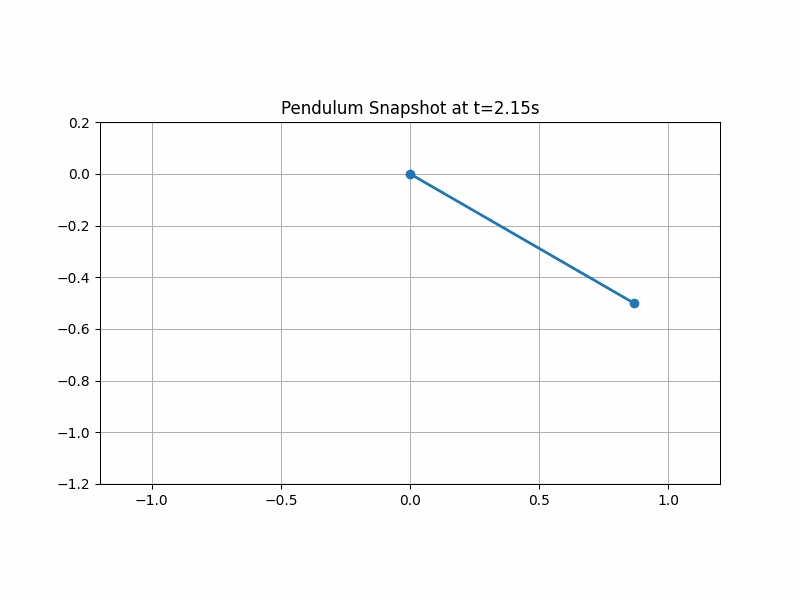

In [8]:
from PIL import Image
import glob
from IPython.display import Image as IPImage, display

# Get PNG files (adjust path / sort as needed)
png_files = sorted(glob.glob("images/snapshot*.png"))

frames = [Image.open(p) for p in png_files]

# Save as GIF
frames[0].save(
    "animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=200,  # milliseconds per frame
    loop=0         # 0 = infinite loop
)

# Display gif within Jupyter
display(IPImage(filename="animation.gif")) 

We indeed see the simulation of a simple pendulum! The agent will occasionally mis-calculate or mis-report its simulated oscillation frequency, but on the whole, the success rate for this prompt is fairly high.

Let's try giving the agent a task that involves more domain-specific information. For this demonstration, we draw an example from fluid dynamics, and ask the agent to simulate the interaction of two point vortices in a potential flow, a classic problem with many existing implementations. This will give us a taste of what an agent it looks like to incorporate domain-specific constraints.

In [10]:
# Incorporate domain-specific knowledge via the prompt
user_input = "Generate a Python Code that simulates two point vortices orbiting one another (Fujiwhara effect). \
The vortcies should be of the same sign and same circulation. \
Advance the simulation for one full period of their orbit, such that the vortices trace a circular trajectory. \
Save 10 flowfields regularly spaced in time from the simulation. The flowfields should show one full orbit of the vortices. \
Return the flowfield snapshots to me as png images. These should be stored in the ./images directory. \
Please do NOT import numpy before installing it. \
"
result = generate_code_agent(user_input = user_input, max_steps = 3, model=backend_model)



--- Step 1 ---
Thought: I need to generate a Python script that simulates two point vortices orbiting each other due to the Fujiwhara effect. The script should advance the simulation for one full orbital period, save 10 flowfield snapshots as PNG images in the ./images directory, and ensure all dependencies are installed using uv. I'll start by writing the code structure, including installing uv and required packages, then implement the vortex simulation and plotting functionality.
Tool Call: GenerateCode
Code generation returned 'success' with the following output: 
Simulation complete. Images saved in ./images directory.


--- Step 2 ---
The task is complete. Here is a final summary of my work: 
I have generated and executed the Python code to simulate two point vortices orbiting each other with the Fujiwhara effect. The simulation ran for one full orbital period, saving 10 flowfield snapshots at regular intervals. All snapshots are stored in the './images' directory as PNG images. 

We can look in the output directory and see exactly what the agent has returned as its simulation.

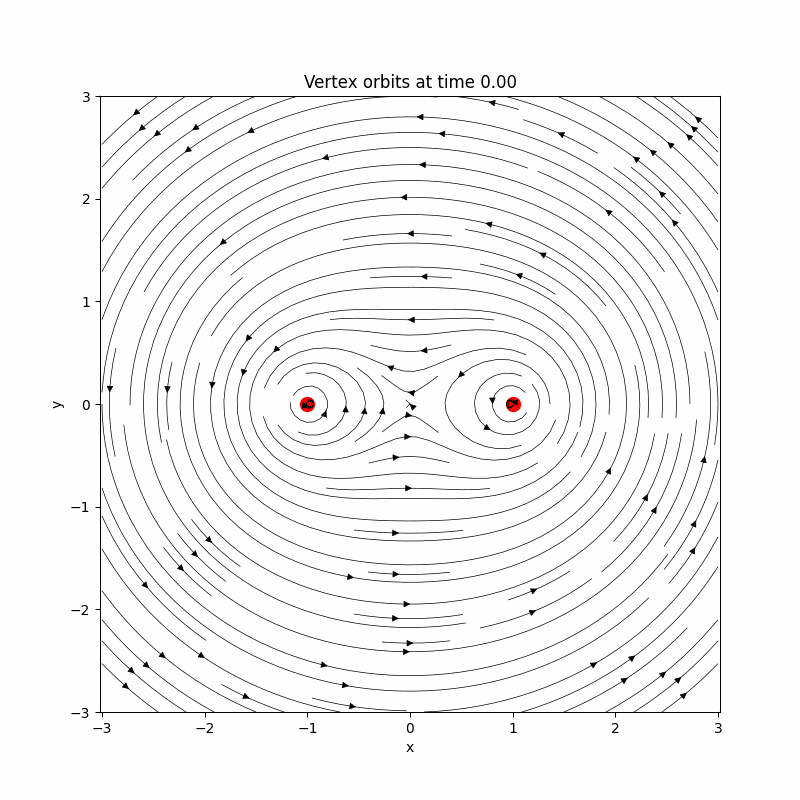

In [11]:
from PIL import Image
import glob
from IPython.display import Image as IPImage, display

# Get PNG files (adjust path / sort as needed)
png_files = sorted(glob.glob("images/*.png"))

frames = [Image.open(p) for p in png_files]

# Save as GIF
frames[0].save(
    "animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=200,  # milliseconds per frame
    loop=0         # 0 = infinite loop
)

# Display gif within Jupyter
display(IPImage(filename="animation.gif")) 

Based on the image sequence above, the agent was indeed able to complete a potential flow simulation, albeit with some questionable image formatting. There are several important observations regarding this outcome: 

- Depending on your back-end model, the agent may have needed several attempts before successfully completing the simulation. This is very normal. In fact it demonstrates a key feature of AI agents: they incorporate observations from previous actions into their plan for next steps. This is one of the core traits that differentiates an AI agent from a traditional LLM.
- The prompt was quite extensive, even for this very simple simulation! One can imagine that if we had asked the agent to write a finite volume solver, the number of failure modes would increase quite a bit, and restrictions in the prompt would need to become more extensive. This is one of the main questions driving research into agentic systems: can we build robust agents without populating their prompts with increasingly complex instructions? Beyond prompt-engineering, techniques for guiding the agent's behavior include dynamic planning, nested schema, and RAG-inspired ingestion; however, solutions to the prompt engineering problem remain an ongoing area of research. 